# Customer Churn Prediction — Exploratory Data Analysis

## Objective
Explore customer characteristics and identify patterns associated with churn.

**Dataset:** IBM Telco Customer Churn

**Rule:** Every visualization must be followed by a plain-English takeaway.

In [28]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').is_dir():
    PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'telco_churn_clean.csv'

df = pd.read_csv(DATA_PATH)

sns.set_theme(style='whitegrid')
print(f'Project root: {PROJECT_ROOT}')
print(f'Dataset shape: {df.shape}')
display(df.head())

Project root: /home/asus/customer-churn-prediction
Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


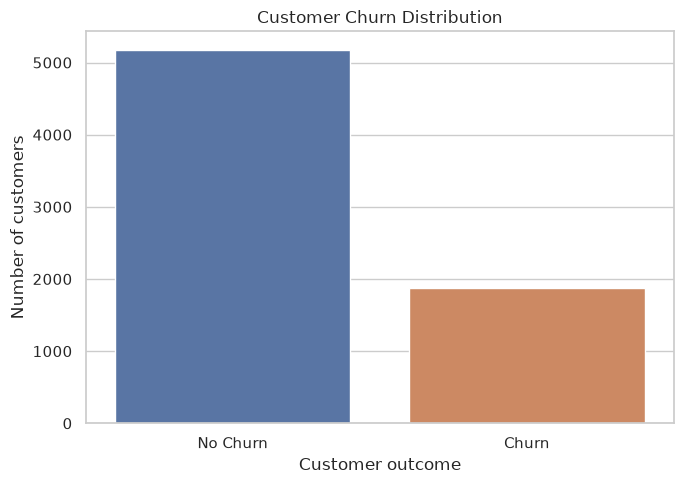

Churn rate: 26.5%


In [35]:
churn_counts = df['Churn'].map({0: 'No Churn', 1: 'Churn'}).value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values,
    hue=churn_counts.index,
    legend=False,
    ax=ax,
)
ax.set_title('Customer Churn Distribution')
ax.set_xlabel('Customer outcome')
ax.set_ylabel('Number of customers')
plt.tight_layout()
plt.show()

print(f'Churn rate: {df["Churn"].mean():.1%}')

**Takeaway:** Approximately 26.5% of customers churn, while 73.5% stay. The classes are imbalanced, so later we must evaluate recall, precision, F1, ROC-AUC, and PR-AUC rather than relying on accuracy alone.

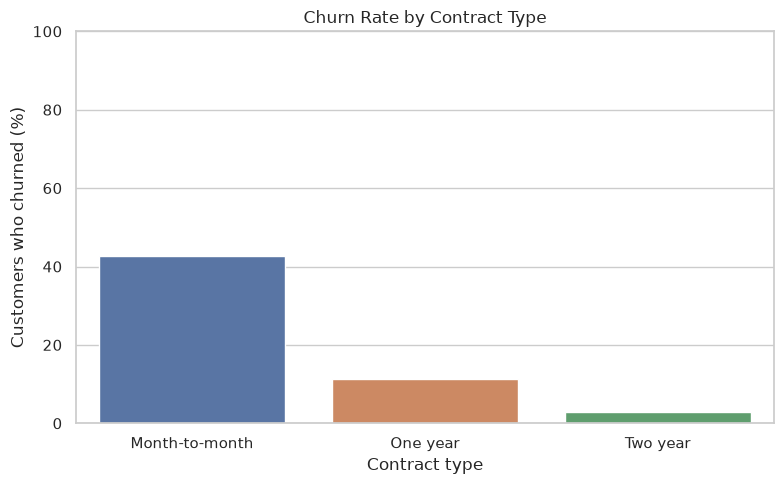

,Contract,Churn rate (%)
0,Month-to-month,42.71
1,One year,11.27
2,Two year,2.83


In [30]:
contract_churn = (
    df.groupby('Contract', observed=True)['Churn']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name='Churn rate (%)')
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=contract_churn,
    x='Contract',
    y='Churn rate (%)',
    hue='Contract',
    legend=False,
    ax=ax,
)
ax.set_title('Churn Rate by Contract Type')
ax.set_xlabel('Contract type')
ax.set_ylabel('Customers who churned (%)')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

display(contract_churn.round(2))

**Takeaway:** Month-to-month customers have a 42.71% churn rate, compared with 11.27% for one-year contracts and 2.83% for two-year contracts. Contract type is strongly associated with churn in this dataset, although this descriptive analysis cannot establish causation.

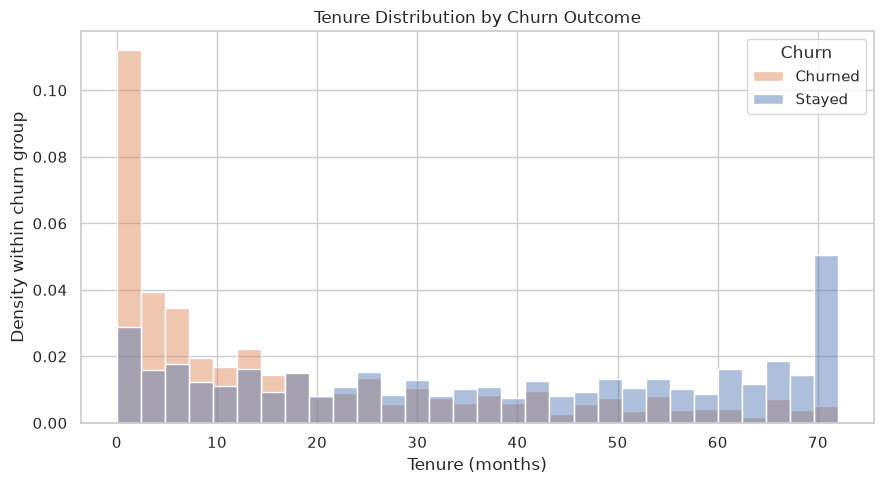

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    bins=30,
    multiple='layer',
    stat='density',
    common_norm=False,
    alpha=0.45,
    ax=ax,
)
ax.set_title('Tenure Distribution by Churn Outcome')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Density within churn group')
ax.legend(title='Churn', labels=['Churned', 'Stayed'])
plt.tight_layout()
plt.show()

**Takeaway:** The tenure distribution shows churn concentrated at low tenure, especially in the first few months. Longer-tenure customers are more represented among those who stayed. This suggests that early customer retention deserves further investigation.

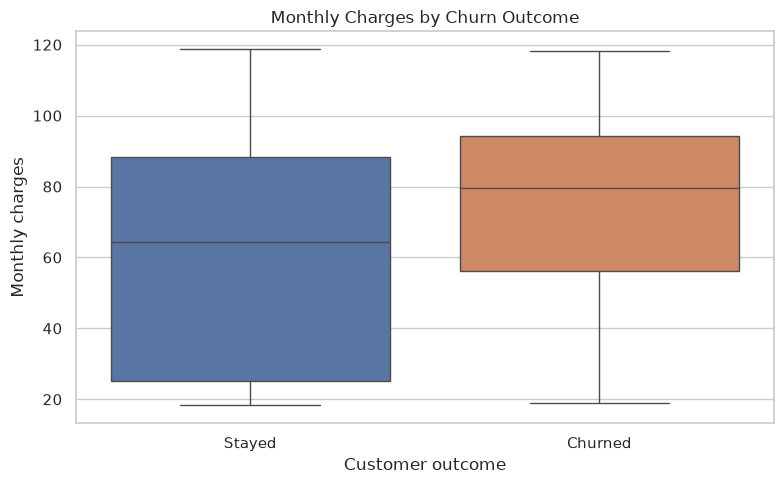

,median,mean
Churn label,,
Churned,79.65,74.44
Stayed,64.43,61.27


In [32]:
df['Churn label'] = df['Churn'].map({0: 'Stayed', 1: 'Churned'})

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df,
    x='Churn label',
    y='MonthlyCharges',
    hue='Churn label',
    legend=False,
    ax=ax,
)
ax.set_title('Monthly Charges by Churn Outcome')
ax.set_xlabel('Customer outcome')
ax.set_ylabel('Monthly charges')
plt.tight_layout()
plt.show()

display(
    df.groupby('Churn label', observed=True)['MonthlyCharges']
    .agg(['median', 'mean'])
    .round(2)
)


**Takeaway:** The median monthly charge is higher among churned customers than among customers who stayed. This association may reflect differences in service mix or contract type; it does not prove that higher prices cause churn.

## Payment Method and Churn

We compare the percentage of customers who churn within each payment method.
Rates are calculated within each payment group, rather than comparing raw counts.


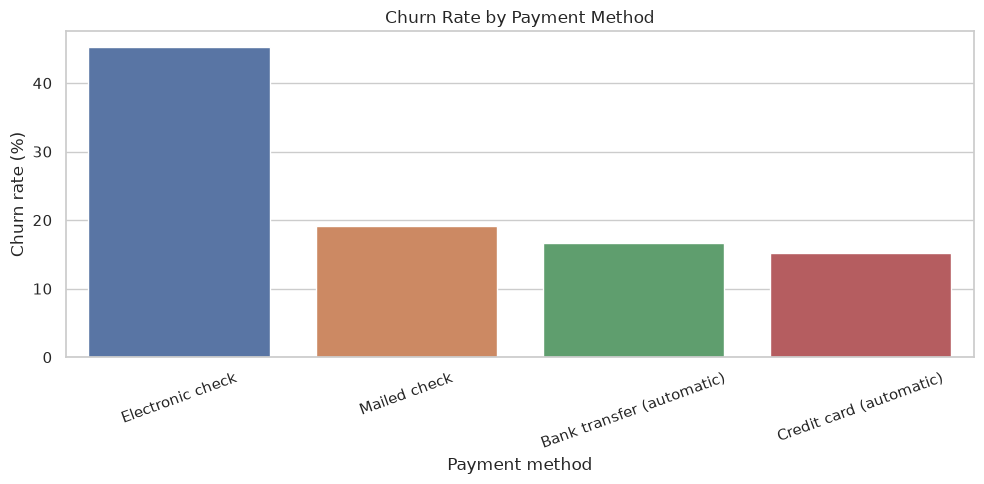

,churn_rate,customers,churn_rate_pct
PaymentMethod,,,
Electronic check,0.453,2365,45.285
Mailed check,0.191,1612,19.107
Bank transfer (automatic),0.167,1544,16.710
Credit card (automatic),0.152,1522,15.243


In [33]:
payment_churn = (
    df.groupby("PaymentMethod", observed=True)["Churn"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "churn_rate", "count": "customers"})
    .sort_values("churn_rate", ascending=False)
)

payment_churn["churn_rate_pct"] = payment_churn["churn_rate"] * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=payment_churn.reset_index(),
    x="PaymentMethod",
    y="churn_rate_pct",
    hue="PaymentMethod",
    legend=False,
    ax=ax,
)
ax.set_title("Churn Rate by Payment Method")
ax.set_xlabel("Payment method")
ax.set_ylabel("Churn rate (%)")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

display(payment_churn.round(3))

**Takeaway:** Use the table above to identify which payment methods have the
highest churn rates and how many customers are in each group. Differences
describe an association, not proof that the payment method causes churn.

## Internet Service and Technical Support

We examine whether churn rates differ across internet service categories and
whether customers with technical support have different observed churn rates.

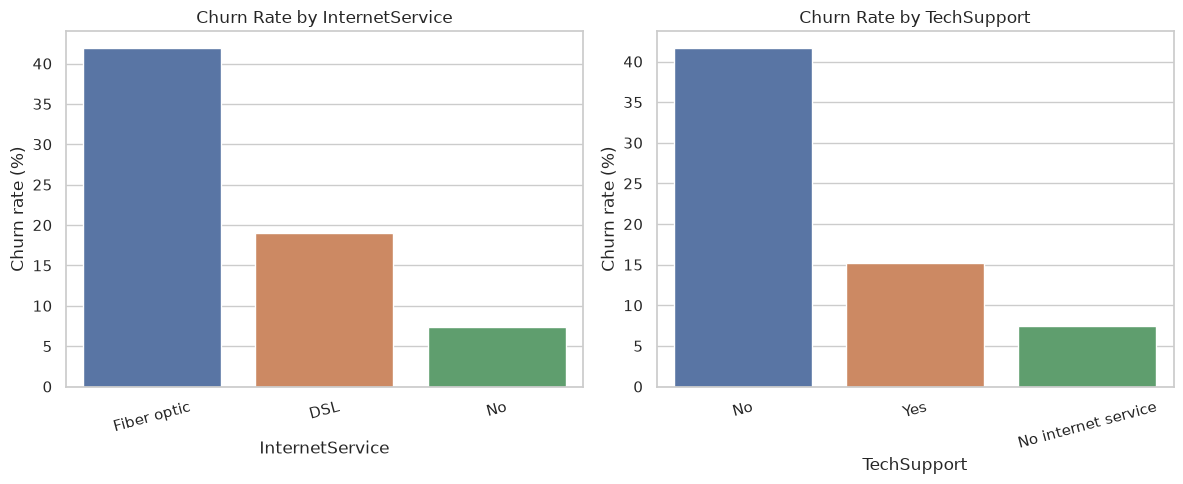

In [34]:
service_columns = ["InternetService", "TechSupport"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, column in zip(axes, service_columns):
    rates = (
        df.groupby(column, observed=True)["Churn"]
        .mean()
        .mul(100)
        .reset_index(name="churn_rate_pct")
        .sort_values("churn_rate_pct", ascending=False)
    )

    sns.barplot(
        data=rates,
        x=column,
        y="churn_rate_pct",
        hue=column,
        legend=False,
        ax=ax,
    )
    ax.set_title(f"Churn Rate by {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Churn rate (%)")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

**Takeaway:** Compare the plotted rates to identify service categories associated
with higher churn. Service availability, customer tenure, and contract type may
also differ between groups, so these plots alone cannot establish causality.

## Churn Rate by Customer Tenure Group

In [ ]:
tenure_bins = [0, 6, 12, 24, 48, 72]
tenure_labels = [
    "0–6 months",
    "7–12 months",
    "13–24 months",
    "25–48 months",
    "49–72 months",
]

tenure_analysis = df.copy()
tenure_analysis["TenureGroup"] = pd.cut(
    tenure_analysis["tenure"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True,
)

tenure_summary = (
    tenure_analysis.groupby("TenureGroup", observed=False)["Churn"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "churn_rate", "count": "customers"})
)
tenure_summary["churn_rate_pct"] = tenure_summary["churn_rate"] * 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=tenure_summary.reset_index(),
    x="TenureGroup",
    y="churn_rate_pct",
    color="steelblue",
    ax=ax,
)
ax.set_title("Churn Rate by Customer Tenure Group")
ax.set_xlabel("Tenure group")
ax.set_ylabel("Churn rate (%)")
plt.tight_layout()
plt.show()

display(tenure_summary.round(3))


**Takeaway:** Churn declines consistently across tenure groups: 52.94% for customers with 0–6 months of tenure, compared with 9.51% for customers with 49–72 months. This pattern suggests that early-tenure retention deserves particular attention. The association is descriptive and does not establish causation.

## Numeric Feature Correlations

This heatmap shows pairwise correlations between numeric columns.
The `customerID` identifier is excluded because it is not a meaningful
numeric feature. Correlation does not establish causation.


In [ ]:
numeric_df = df.select_dtypes(include="number").drop(
    columns=["customerID"], errors="ignore"
)
correlation = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()

display(
    correlation["Churn"]
    .drop("Churn")
    .sort_values(key=abs, ascending=False)
    .to_frame("correlation_with_churn")
)


**Takeaway:** Use the heatmap and correlation table to identify numeric
features with stronger positive or negative linear associations with churn.
These correlations are exploratory, may reflect relationships with other
features, and do not establish causation.
